In [ ]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display

#set maximum column width to make displays more readable 
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_columns", 13)

In [ ]:
# load the transcript
dataset = "dataset.csv"

df = pd.read_csv(dataset)

# TA nulls: check for session with missing values 
ta_nulls = df["TA"].isnull().sum()

print(f"Dataset loaded")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"TA nulls: {ta_nulls:,} ({ta_nulls/len(df)*100:.1f}%)")
print(f"Note: nulls are concentrated in sessions 2, 3, 7, 19, 24, 26, 28. These session have no recording of TA")

Dataset loaded
Shape   : 10,799 rows × 13 columns
TA nulls: 2,526 (23.4%)
Note: nulls are concentrated in sessions 2, 3, 7, 19, 24, 26, 28. These session have no recording of TA


In [13]:
#show some samples of the dataset 
display(df.head(10))

,session,start,end,speaker,content,ep,C,E,M,T,TA,MC,RA
0,1,00:00:02,00:00:05,Christopher,And for every stage of person.,0,0,0,0,0,0.0,0,0
1,1,00:00:10,00:02:04,Brian,"I think the access to, I was the one that said access, but I think we're go...",1,0,0,0,0,0.0,0,0
2,1,00:02:08,00:03:03,Brian,"Because we're thinking about it, and now you see quantitative data when may...",1,0,0,0,0,0.0,0,0
3,1,00:03:03,00:03:05,Christopher,Is it like teacher-learner?,1,0,0,0,0,0.0,0,0
4,1,00:03:05,00:04:11,Brian,"Yeah, something like that, but the one that I work with was specific for cu...",1,0,0,0,0,0.0,0,0
5,1,00:04:15,00:04:27,Christopher,How about your job in masterclass? Is it open access or is it for a certain...,1,1,0,0,0,0.0,0,0
6,1,00:04:27,00:04:37,Brian,"No, I didn't work in masterclass. It was an example because it's closed. Bu...",1,0,0,0,0,0.0,1,0
7,1,00:04:38,00:04:40,Christopher,Is it like open access for everyone or a certain group?,1,1,0,0,0,0.0,0,0
8,1,00:04:40,00:05:39,Brian,"No, so we have this thing, we have some courses that you have to pay for, r...",1,0,1,0,0,0.0,1,0
9,1,00:05:39,00:07:01,Christopher,I'm interested in simplifying it into like easy courses. I have an interes...,1,0,0,0,0,0.0,0,0


In [14]:
#check column names , type and null count 

info = pd.DataFrame({
    "dtype": df.dtypes,
    "nulls": df.isnull().sum(),
    "unique": df.nunique(),
})
display(info)


,dtype,nulls,unique
session,int64,0,28
start,object,0,3431
end,object,0,3449
speaker,object,5,29
content,object,0,9365
ep,int64,0,56
C,int64,0,2
E,int64,0,2
M,int64,0,2
T,int64,0,2


 Total utterances : 10,799
 Total sessions : 28
 Total episodes: 882

Utterances per episode:
  Mean : 12.2
  Median : 8.0
  Min : 1
  Max : 130


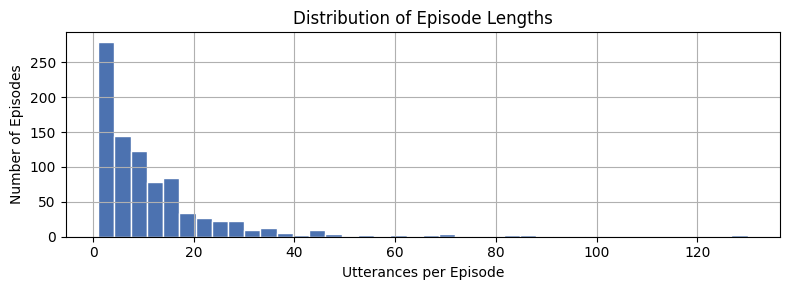

In [15]:
#calculate the basic statistics 

n_utterances = len(df)
n_sessions = df["session"].nunique()
n_episodes = df.groupby(["session", "ep"]).ngroups

utt_per_ep= df.groupby(["session", "ep"]).size()

print("=" * 40)
print(f" Total utterances : {n_utterances:,}")
print(f" Total sessions : {n_sessions}")
print(f" Total episodes: {n_episodes}")
print("=" * 40)
print(f"\nUtterances per episode:")
print(f"  Mean : {utt_per_ep.mean():.1f}")
print(f"  Median : {utt_per_ep.median():.1f}")
print(f"  Min : {utt_per_ep.min()}")
print(f"  Max : {utt_per_ep.max()}")

# Distribution plot
fig, ax = plt.subplots(figsize=(8, 3))
utt_per_ep.hist(bins=40, ax=ax, color="#4C72B0", edgecolor="white")
ax.set_xlabel("Utterances per Episode")
ax.set_ylabel("Number of Episodes")
ax.set_title("Distribution of Episode Lengths")
plt.tight_layout()
plt.show()


,Full name,Count (=1),% of total
C,Cognitive challenge,814,7.5%
E,Emotional/motivational challenge,112,1.0%
M,Metacognitive challenge,327,3.0%
T,Technical/other challenge,198,1.8%
TA,Task Analysis,285,3.4%
MC,Monitoring / Control,6553,60.7%
RA,Reflection / Adaptation,122,1.1%


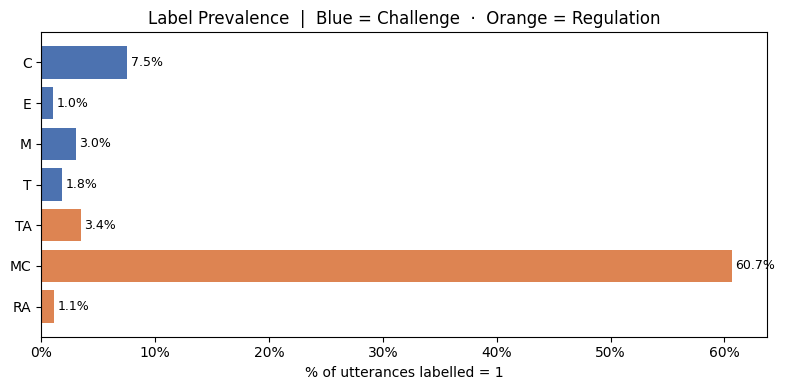

In [16]:
#check the distribution of the exisiting labels 

LABEL_COLS = ["C", "E", "M", "T", "TA", "MC", "RA"]
LABEL_NAMES = {
    "C" : "Cognitive challenge",
    "E" : "Emotional/motivational challenge",
    "M" : "Metacognitive challenge",
    "T" : "Technical/other challenge",
    "TA" : "Task Analysis",
    "MC" : "Monitoring / Control",
    "RA" : "Reflection / Adaptation",
}

label_stats = pd.DataFrame({
    "Full name": [LABEL_NAMES[c] for c in LABEL_COLS],
    "Count (=1)": [int(df[c].sum()) for c in LABEL_COLS],
    "% of total": [df[c].mean() * 100 for c in LABEL_COLS],
}, index=LABEL_COLS)

display(label_stats.style.format({"% of total": "{:.1f}%"}))

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#DD8452" if c in ["TA","MC","RA"] else "#4C72B0" for c in LABEL_COLS]
ax.barh(LABEL_COLS[::-1], label_stats["% of total"][::-1], color=colors[::-1])
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel("% of utterances labelled = 1")
ax.set_title("Label Prevalence  |  Blue = Challenge  ·  Orange = Regulation")
for i, (col, row) in enumerate(label_stats[::-1].iterrows()):
    ax.text(row["% of total"] + 0.3, i, f'{row["% of total"]:.1f}%', va="center", fontsize=9)
plt.tight_layout()
plt.show()


In [17]:
#regulation scores at episode level 

ep_df = df.groupby(["session", "ep"]).agg(
    utterances = ("content", "count"),
    TA_sum  = ("TA", "sum"),
    MC_sum = ("MC", "sum"),
    RA_sum  = ("RA", "sum"),
    C_sum  = ("C",  "sum"),
    E_sum = ("E",  "sum"),
    M_sum = ("M",  "sum"),
    T_sum = ("T",  "sum"),
).reset_index()

# Total regulation events and density (proportion of utterances with any regulation)
ep_df["reg_total"] = ep_df["TA_sum"] + ep_df["MC_sum"] + ep_df["RA_sum"]
ep_df["reg_density"] = ep_df["reg_total"] / ep_df["utterances"]

print(f"Episode-level dataframe: {ep_df.shape[0]} episodes")
display(ep_df.head())

Episode-level dataframe: 882 episodes


,session,ep,utterances,TA_sum,MC_sum,RA_sum,C_sum,E_sum,M_sum,T_sum,reg_total,reg_density
0,1,0,1,0.0,0,0,0,0,0,0,0.0,0.000000
1,1,1,9,0.0,2,0,2,1,0,0,2.0,0.222222
2,1,2,4,0.0,2,0,0,0,1,0,2.0,0.500000
3,1,3,15,0.0,15,0,0,0,0,0,15.0,1.000000
4,1,4,16,0.0,10,0,2,0,0,0,10.0,0.625000


In [ ]:
# identify sessions with missing TA annotation from the raw data
# Group the dataframe by session and check the "TA" column in each session.
TA_missing = df.groupby("session")["TA"].apply(lambda x: x.isnull().all())
# Keep only the sessions where the result is True,
TA_missing = TA_missing[TA_missing].index.tolist()

unknown_eps= ep_df[ep_df["session"].isin(TA_missing)][["session", "ep", "utterances"]]
# Print the list of sessions that have no TA annotation at all.
print(f"Sessions with no TA annotation: {TA_missing}")
print(f"Affected episodes: {len(unknown_eps)} across {unknown_eps['session'].nunique()} sessions\n")
display(unknown_eps.reset_index(drop=True))

Sessions with no TA annotation: [2, 3, 7, 19, 24, 26, 28]
Affected episodes: 242 across 7 sessions



,session,ep,utterances
0,2,0,1
1,2,1,1
2,2,2,12
3,2,3,13
4,2,4,48
...,...,...,...
237,28,9,22
238,28,10,2
239,28,11,10
240,28,12,14


In [ ]:

# select appropriate episodes to test with
# exclude sessions where TA was never annotated from selection 
TA_Unkown = [2, 3, 7, 19, 24, 26, 28]

# Only consider episodes with >= 8 utterances AND from fully annotated sessions
valid = ep_df[
    (ep_df["utterances"] >= 8) &
    (~ep_df["session"].isin(TA_Unkown))
].copy()

# High: maximum regulation density
high_ep = valid.sort_values("reg_density", ascending=False).iloc[0]

# Low: zero regulation, largest episode
low_ep = valid[valid["reg_density"] == 0].sort_values("utterances", ascending=False).iloc[0]

# Mixed: closest to median regulation density
mid_val = valid["reg_density"].median()
mixed_ep = valid.iloc[(valid["reg_density"] - mid_val).abs().argsort().iloc[0]]

test_episodes = {
    "High": high_ep,
    "Low": low_ep,
    "Mixed": mixed_ep,
}

for label, row in test_episodes.items():
    print(f"{'─'*50}")
    print(f"  [{label} regulation]  Session={int(row['session'])}, Episode={int(row['ep'])}")
    print(f"  Utterances  : {int(row['utterances'])}")
    print(f"  Reg density : {row['reg_density']:.3f}")
    print(f"  TA={int(row['TA_sum'])}  MC={int(row['MC_sum'])}  RA={int(row['RA_sum'])}")
    print(f"  Challenges — C={int(row['C_sum'])} E={int(row['E_sum'])} M={int(row['M_sum'])} T={int(row['T_sum'])}")
print(f"{'─'*50}")


──────────────────────────────────────────────────
  [High regulation]  Session=14, Episode=18
  Utterances  : 12
  Reg density : 1.000
  TA=0  MC=12  RA=0
  Challenges — C=0 E=0 M=0 T=1
──────────────────────────────────────────────────
  [Low regulation]  Session=17, Episode=38
  Utterances  : 16
  Reg density : 0.000
  TA=0  MC=0  RA=0
  Challenges — C=0 E=0 M=0 T=1
──────────────────────────────────────────────────
  [Mixed regulation]  Session=1, Episode=15
  Utterances  : 13
  Reg density : 0.769
  TA=0  MC=10  RA=0
  Challenges — C=1 E=0 M=2 T=0
──────────────────────────────────────────────────


In [25]:
#show uttereances for each test episode 

for label, row in test_episodes.items():
    s, e = int(row["session"]), int(row["ep"])
    subset = df[(df["session"] == s) & (df["ep"] == e)][
        ["speaker", "content", "C", "E", "M", "T", "TA", "MC", "RA"]
    ].reset_index(drop=True)
    print(f"\n{'-'*60}")
    print(f"  {label} regulation  |  Session {s}, Episode {e}  ({len(subset)} utterances)")
    print(f"{'-'*60}")
    display(subset)



------------------------------------------------------------
  High regulation  |  Session 14, Episode 18  (12 utterances)
------------------------------------------------------------


,speaker,content,C,E,M,T,TA,MC,RA
0,Daniel,So I guess you're supposed to relate the features to the type of dimension....,0,0,0,1,0.0,1,0
1,Susan,Which one?,0,0,0,0,0.0,1,0
2,Daniel,"The one they suggest. Yeah, this paper.",0,0,0,0,0.0,1,0
3,Susan,This paper?,0,0,0,0,0.0,1,0
4,Daniel,Yeah.,0,0,0,0,0.0,1,0
5,Susan,So you can't open it?,0,0,0,0,0.0,1,0
6,Daniel,"I can't, I tried to open it. Like...",0,0,0,0,0.0,1,0
7,Susan,"Okay, okay, let me see.",0,0,0,0,0.0,1,0
8,Susan,Okay.,0,0,0,0,0.0,1,0
9,Daniel,"It gives the abstract, but it doesn't give you the full answer.",0,0,0,0,0.0,1,0



------------------------------------------------------------
  Low regulation  |  Session 17, Episode 38  (16 utterances)
------------------------------------------------------------


,speaker,content,C,E,M,T,TA,MC,RA
0,Daniel,"What do you think that in terms of value, high value, intrusiveness, low ...",0,0,0,0,0.0,0,0
1,James,"Actually, I think we need to be more you know, actually I think we need ...",0,0,0,0,0.0,0,0
2,Anthony,"So that's why we're going to need the multimodal data, so that is one of i...",0,0,0,0,0.0,0,0
3,James,"Yeah, so like the neutral gaze.",0,0,0,0,0.0,0,0
4,Anthony,I think we can copy from the data. I don't know where is it.,0,0,0,1,0.0,0,0
5,James,How can does that mean the students are required to turn on their video?,0,0,0,0,0.0,0,0
6,Susan,The camera.,0,0,0,0,0.0,0,0
7,James,The cameras while having the.,0,0,0,0,0.0,0,0
8,Anthony,Because I was discussing with <person> in terms of LMS whether that is po...,0,0,0,0,0.0,0,0
9,Daniel,"For our design case, are we measuring that sort of stuff from the student...",0,0,0,0,0.0,0,0



------------------------------------------------------------
  Mixed regulation  |  Session 1, Episode 15  (13 utterances)
------------------------------------------------------------


,speaker,content,C,E,M,T,TA,MC,RA
0,Lisa,So what are the main challenges our group wants to solve?,0,0,0,0,0.0,1,0
1,Lisa,So what will our group just want to solve the actual challenge? So which c...,0,0,0,0,0.0,1,0
2,Karen,We need to decide along this term?,0,0,1,0,0.0,0,0
3,Lisa,"In week 1 we need to decide which challenge, then in this term we need to s...",0,0,0,0,0.0,1,0
4,Karen,It's a big decision. I think we need just more time.,0,0,0,0,0.0,1,0
5,Brian,I want to ask everybody what they're doing.,0,0,0,0,0.0,1,0
6,Brian,Because now I've seen like this example.,0,0,0,0,0.0,1,0
7,Brian,"There's an example here. And I'm gonna show you. For example, these peopl...",0,0,0,0,0.0,1,0
8,Lisa,Are you guys decided to do the kindergarten?,0,0,1,0,0.0,0,0
9,Brian,We also talked about primary school.,0,0,0,0,0.0,1,0


In [26]:
# Save cleaned dataset
# df.to_csv("dataset_cleaned.csv", index=False)
# print("Saved: dataset_cleaned.csv")

# Save episode-level dataframe
ep_df.to_csv("episode_features.csv", index=False)
print("Saved: episode_features.csv")

# Save the 3 test episodes as JSON for use in the pipeline
output = {}
for label, row in test_episodes.items():
    s, e = int(row["session"]), int(row["ep"])
    ep_data = df[(df["session"] == s) & (df["ep"] == e)].copy()
    output[label] = {
        "meta": {
            "label": label,
            "session": s,
            "ep": e,
            "utterances" : int(row["utterances"]),
            "reg_density": round(float(row["reg_density"]), 3),
            "TA_sum": int(row["TA_sum"]),
            "MC_sum": int(row["MC_sum"]),
            "RA_sum": int(row["RA_sum"]),
        },
        "utterances": ep_data[
            ["speaker", "content", "C", "E", "M", "T", "TA", "MC", "RA"]
        ].to_dict(orient="records"),
    }

with open("test_episodes.json", "w") as f:
    json.dump(output, f, indent=2)
print("Saved: test_episodes.json")



Saved: episode_features.csv
Saved: test_episodes.json
